# Eksperimen Semua Skenario (S1–S8) pada Berbagai Rasio Split

**Modifikasi dari kode utama** dengan tambahan:
1. Pengecekan & penghapusan duplikasi data **sebelum imputasi**
2. Loop eksperimen untuk rasio split: **70/30 · 75/25 · 80/20 · 85/15**
3. Rekap perbandingan antar rasio untuk seluruh skenario

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE
from sklearn.base import clone
import warnings, time
warnings.filterwarnings("ignore")

## 1. Load Data

In [2]:
DATA_PATH = "diabetes_1.csv"
data_raw = pd.read_csv(DATA_PATH)
print(f"Jumlah data awal : {len(data_raw)} baris")
print(f"Jumlah kolom     : {len(data_raw.columns)}")
data_raw.head()

Jumlah data awal : 2000 baris
Jumlah kolom     : 9


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138,62,35,0,33.6,0.127,47,1
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,1
3,0,135,68,42,250,42.3,0.365,24,1
4,1,139,62,41,480,40.7,0.536,21,0


## 2. Pengecekan & Penghapusan Duplikasi Data

Dilakukan **sebelum imputasi** agar data duplikat tidak ikut mempengaruhi estimasi nilai median/imputer.

In [3]:
jumlah_duplikat = data_raw.duplicated().sum()
print(f"Jumlah baris duplikat : {jumlah_duplikat}")
if jumlah_duplikat > 0:
    print("\nContoh baris duplikat:")
    display(data_raw[data_raw.duplicated(keep=False)].sort_values(list(data_raw.columns)).head(10))
    data_raw = data_raw.drop_duplicates().reset_index(drop=True)
    print(f"\nJumlah data setelah penghapusan duplikat : {len(data_raw)} baris")
else:
    print("Tidak ada duplikasi data. Tidak ada baris yang dihapus.")

Jumlah baris duplikat : 1256

Contoh baris duplikat:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
537,0,57,60,0,0,21.7,0.735,67,0
994,0,57,60,0,0,21.7,0.735,67,0
596,0,67,76,0,0,45.3,0.194,46,0
1053,0,67,76,0,0,45.3,0.194,46,0
589,0,73,0,0,0,21.1,0.342,25,0
1046,0,73,0,0,0,21.1,0.342,25,0
466,0,74,52,10,36,27.8,0.269,22,0
936,0,74,52,10,36,27.8,0.269,22,0
1525,0,74,52,10,36,27.8,0.269,22,0
290,0,78,88,29,40,36.9,0.434,21,0



Jumlah data setelah penghapusan duplikat : 744 baris


## 3. Pengecekan Nilai 0 (Missing Values Terselubung)

In [4]:
print("Nilai 0 pada setiap kolom:")
for kolom in data_raw.columns:
    if kolom != 'Outcome':
        hitung_nol = (data_raw[kolom] == 0).sum()
        print(f"  {kolom}: {hitung_nol}")

fitur_dengan_nol = data_raw.drop(['Outcome', 'Pregnancies'], axis=1) == 0
total_baris_nol  = fitur_dengan_nol.any(axis=1).sum()
persentase_baris_nol = (total_baris_nol / len(data_raw)) * 100
print(f"\nTotal baris dengan min. 1 nilai 0 : {total_baris_nol}")
print(f"Persentase                         : {persentase_baris_nol:.2f}%")

Nilai 0 pada setiap kolom:
  Pregnancies: 112
  Glucose: 5
  BloodPressure: 34
  SkinThickness: 215
  Insulin: 359
  BMI: 10
  DiabetesPedigreeFunction: 0
  Age: 0

Total baris dengan min. 1 nilai 0 : 363
Persentase                         : 48.79%


## 4. Imputasi Nilai 0 (Median)

In [5]:
kolom_hilang = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
data = data_raw.copy()
data[kolom_hilang] = data[kolom_hilang].replace(0, np.nan)

if persentase_baris_nol > 10:
    # pakai knni
    imputer = KNNImputer(n_neighbors=5)
    data[kolom_hilang] = imputer.fit_transform(data[kolom_hilang])
    print(f"Imputasi KNN selesai. Missing values sisa:\n{data.isnull().sum()}")
else:
    data = data.dropna(subset=kolom_hilang).reset_index(drop=True)
    print(f"Jumlah data setelah drop baris NaN: {len(data)}")

print(f"\nTotal data bersih siap digunakan: {len(data)} baris")

Imputasi KNN selesai. Missing values sisa:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Total data bersih siap digunakan: 744 baris


## 5. Normalisasi (MinMaxScaler)

In [6]:
X_all = data.drop(columns=["Outcome"])
y_all = data["Outcome"]
min_max = MinMaxScaler()
X_norm = pd.DataFrame(min_max.fit_transform(X_all), columns=X_all.columns)
print(f"Shape setelah normalisasi: {X_norm.shape}")
print(f"Distribusi kelas: {y_all.value_counts().to_dict()}")

Shape setelah normalisasi: (744, 8)
Distribusi kelas: {0: 491, 1: 253}


## 6. Definisi Fungsi Bantu

In [7]:
def evaluasi_testing(nama, y_asli, y_pred):
    return {
        "Model"   : nama,
        "Akurasi" : round(accuracy_score(y_asli, y_pred), 4),
        "Presisi" : round(precision_score(y_asli, y_pred, zero_division=0), 4),
        "Recall"  : round(recall_score(y_asli, y_pred, zero_division=0), 4),
        "F1-Score": round(f1_score(y_asli, y_pred, zero_division=0), 4),
    }

def cetak_evaluasi(nama, y_asli, y_pred):
    h = evaluasi_testing(nama, y_asli, y_pred)
    print(f"  Hasil Evaluasi Testing – {nama}")
    print(f"  Akurasi  : {h['Akurasi']:.4f}")
    print(f"  Presisi  : {h['Presisi']:.4f}")
    print(f"  Recall   : {h['Recall']:.4f}")
    print(f"  F1-Score : {h['F1-Score']:.4f}")
    return h

def plot_cm(nama, y_asli, y_pred, ax=None):
    cm = confusion_matrix(y_asli, y_pred)
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Non Diabetes","Diabetes"],
                yticklabels=["Non Diabetes","Diabetes"],
                annot_kws={"size":14})
    ax.set_title(f"CM – {nama}", fontsize=11)
    ax.set_xlabel("Prediksi", fontsize=10)
    ax.set_ylabel("Aktual", fontsize=10)
    if standalone:
        plt.tight_layout(); plt.show(); plt.close(fig)

print("Fungsi bantu siap.")

Fungsi bantu siap.


## 7. Parameter Grid (sama persis dengan kode utama)

In [8]:
param_grid_knn = {
    "n_neighbors": [5, 7, 9, 11, 13, 15, 17, 19],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"],
}
param_grid_lr = {
    "C": np.logspace(-4, 4, 20),
    "solver": ["liblinear", "lbfgs"],
    "penalty": ["l1", "l2"],
}
param_grid_svm = {
    "C": [0.1, 1, 10, 100, 1000],
    "gamma": ["scale", "auto"],
    "kernel": ["rbf", "linear"],
}
param_grid_ann = {
    "max_iter": [100, 500, 1000],
    "hidden_layer_sizes": [(100,), (50, 50), (30, 20), (20, 10)],
    "activation": ["relu", "tanh", "logistic"],
    "learning_rate_init": [0.0001, 0.001],
}
RASIO_SPLIT = {
    "70/30": 0.30,
    "80/20": 0.20,
    "90/10": 0.10,
}
print("Parameter grid & rasio split siap.")

Parameter grid & rasio split siap.


## 8. Eksperimen Loop – Semua Rasio Split × Semua Skenario

> Setiap iterasi menjalankan pipeline lengkap:
> split → SMOTE → KFold CV → GridSearch (S1–S4) → meta-features → GridSearch meta-learner (S5–S8)

In [9]:
semua_hasil_rasio = []   # rekap akhir lintas rasio

for label_rasio, test_size in RASIO_SPLIT.items():
    print("\n" + "="*65)
    print(f"  RASIO SPLIT  :  Train / Test  =  {label_rasio}")
    print("="*65)

    # ── 1. SPLIT ──────────────────────────────────────────────────────
    X_train, X_test, y_train, y_test = train_test_split(
        X_norm, y_all, test_size=test_size, random_state=42
    )
    print(f"Data train : {len(X_train)}  |  Data test : {len(X_test)}")

    # ── 2. SMOTE ──────────────────────────────────────────────────────
    IR = y_train.value_counts().max() / y_train.value_counts().min()
    if IR > 1.5:
        X_train_s, y_train_s = SMOTE(random_state=42).fit_resample(X_train, y_train)
    else:
        X_train_s, y_train_s = X_train.copy(), y_train.copy()
    print(f"Data train setelah SMOTE : {len(X_train_s)}  (IR sebelum={IR:.2f})")

    # ── 3. KFOLD ──────────────────────────────────────────────────────
    kfold = KFold(n_splits=5, shuffle=True, random_state=42)

    # ── SKENARIO 1 – KNN BASE ─────────────────────────────────────────
    print("\n  [S1 KNN] training...")
    _t0 = time.time()
    grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn,
                            cv=kfold, scoring="accuracy", n_jobs=-1, verbose=0)
    grid_knn.fit(X_train_s, y_train_s)
    wt_knn = (time.time()-_t0)*1000
    knn_final = grid_knn.best_estimator_
    _t0 = time.time()
    y_pred_knn = knn_final.predict(X_test)
    wp_knn = (time.time()-_t0)*1000
    h_knn = cetak_evaluasi(f"S1 KNN [{label_rasio}]", y_test, y_pred_knn)
    print(f"  Best params : {grid_knn.best_params_}  |  CV={grid_knn.best_score_:.4f}")
    print(f"  Waktu train : {wt_knn:.1f} ms  |  predict : {wp_knn:.2f} ms")

    # ── SKENARIO 2 – LR BASE ──────────────────────────────────────────
    print("\n  [S2 LR] training...")
    _t0 = time.time()
    grid_lr = GridSearchCV(LogisticRegression(random_state=42), param_grid_lr,
                           cv=kfold, scoring="accuracy", n_jobs=-1, verbose=0)
    grid_lr.fit(X_train_s, y_train_s)
    wt_lr = (time.time()-_t0)*1000
    lr_final = grid_lr.best_estimator_
    _t0 = time.time()
    y_pred_lr = lr_final.predict(X_test)
    wp_lr = (time.time()-_t0)*1000
    h_lr = cetak_evaluasi(f"S2 LR [{label_rasio}]", y_test, y_pred_lr)
    print(f"  Best params : {grid_lr.best_params_}  |  CV={grid_lr.best_score_:.4f}")
    print(f"  Waktu train : {wt_lr:.1f} ms  |  predict : {wp_lr:.2f} ms")

    # ── SKENARIO 3 – SVM BASE ─────────────────────────────────────────
    print("\n  [S3 SVM] training...")
    _t0 = time.time()
    grid_svm = GridSearchCV(SVC(random_state=42, probability=True), param_grid_svm,
                            cv=kfold, scoring="accuracy", n_jobs=-1, verbose=0)
    grid_svm.fit(X_train_s, y_train_s)
    wt_svm = (time.time()-_t0)*1000
    svm_final = grid_svm.best_estimator_
    _t0 = time.time()
    y_pred_svm = svm_final.predict(X_test)
    wp_svm = (time.time()-_t0)*1000
    h_svm = cetak_evaluasi(f"S3 SVM [{label_rasio}]", y_test, y_pred_svm)
    print(f"  Best params : {grid_svm.best_params_}  |  CV={grid_svm.best_score_:.4f}")
    print(f"  Waktu train : {wt_svm:.1f} ms  |  predict : {wp_svm:.2f} ms")

    # ── SKENARIO 4 – ANN BASE ─────────────────────────────────────────
    print("\n  [S4 ANN] training...")
    _t0 = time.time()
    grid_ann = GridSearchCV(MLPClassifier(random_state=42), param_grid_ann,
                            cv=kfold, scoring="accuracy", n_jobs=-1, verbose=0)
    grid_ann.fit(X_train_s, y_train_s)
    wt_ann = (time.time()-_t0)*1000
    ann_final = grid_ann.best_estimator_
    _t0 = time.time()
    y_pred_ann = ann_final.predict(X_test)
    wp_ann = (time.time()-_t0)*1000
    h_ann = cetak_evaluasi(f"S4 ANN [{label_rasio}]", y_test, y_pred_ann)
    print(f"  Best params : {grid_ann.best_params_}  |  CV={grid_ann.best_score_:.4f}")
    print(f"  Waktu train : {wt_ann:.1f} ms  |  predict : {wp_ann:.2f} ms")

    # ── META-FEATURES ─────────────────────────────────────────────────
    print("\n  [META] membangun meta-features training & testing...")
    models_base = [
        ("knn", knn_final), ("lr", lr_final),
        ("svm", svm_final), ("ann", ann_final),
    ]
    _t0_mt = time.time()
    dataset_train_meta = []
    for tr_idx, val_idx in kfold.split(X_train_s, y_train_s):
        X_tr  = X_train_s.iloc[tr_idx];  y_tr  = y_train_s.iloc[tr_idx]
        X_val = X_train_s.iloc[val_idx]
        fold_preds = []
        for nm, est in models_base:
            m = clone(est); m.fit(X_tr, y_tr)
            proba = m.predict_proba(X_val)
            fold_preds.append(pd.DataFrame(proba, index=val_idx,
                              columns=[f"{nm}_prob_0", f"{nm}_prob_1"]))
        dataset_train_meta.append(pd.concat(fold_preds, axis=1))
    X_meta_latih = pd.concat(dataset_train_meta).sort_index()
    y_meta_latih = y_train_s
    wt_meta_build = (time.time()-_t0_mt)*1000

    _t0_mt2 = time.time()
    X_meta_uji = pd.concat([
        pd.DataFrame(est.predict_proba(X_test),
                     columns=[f"{nm}_prob_0", f"{nm}_prob_1"])
        for nm, est in models_base
    ], axis=1)
    y_meta_uji = y_test
    wp_meta_build = (time.time()-_t0_mt2)*1000
    print(f"  Meta-features train: {X_meta_latih.shape}  |  test: {X_meta_uji.shape}")

    # ── SKENARIO 5 – META-KNN ─────────────────────────────────────────
    print("\n  [S5 Meta-KNN] training...")
    _t0 = time.time()
    grid_knn_meta = GridSearchCV(KNeighborsClassifier(), param_grid_knn,
                                 cv=kfold, scoring="accuracy", n_jobs=-1, verbose=0)
    grid_knn_meta.fit(X_meta_latih, y_meta_latih)
    wt_knn_m = (time.time()-_t0)*1000
    knn_meta_final = grid_knn_meta.best_estimator_
    _t0 = time.time()
    y_pred_knn_m = knn_meta_final.predict(X_meta_uji)
    wp_knn_m = (time.time()-_t0)*1000
    h_knn_m = cetak_evaluasi(f"S5 Meta-KNN [{label_rasio}]", y_meta_uji, y_pred_knn_m)
    print(f"  Best params : {grid_knn_meta.best_params_}  |  CV={grid_knn_meta.best_score_:.4f}")

    # ── SKENARIO 6 – META-LR ──────────────────────────────────────────
    print("\n  [S6 Meta-LR] training...")
    _t0 = time.time()
    grid_lr_meta = GridSearchCV(LogisticRegression(random_state=42), param_grid_lr,
                                cv=kfold, scoring="accuracy", n_jobs=-1, verbose=0)
    grid_lr_meta.fit(X_meta_latih, y_meta_latih)
    wt_lr_m = (time.time()-_t0)*1000
    lr_meta_final = grid_lr_meta.best_estimator_
    _t0 = time.time()
    y_pred_lr_m = lr_meta_final.predict(X_meta_uji)
    wp_lr_m = (time.time()-_t0)*1000
    h_lr_m = cetak_evaluasi(f"S6 Meta-LR [{label_rasio}]", y_meta_uji, y_pred_lr_m)
    print(f"  Best params : {grid_lr_meta.best_params_}  |  CV={grid_lr_meta.best_score_:.4f}")

    # ── SKENARIO 7 – META-SVM ─────────────────────────────────────────
    print("\n  [S7 Meta-SVM] training...")
    _t0 = time.time()
    grid_svm_meta = GridSearchCV(SVC(random_state=42, probability=True), param_grid_svm,
                                 cv=kfold, scoring="accuracy", n_jobs=-1, verbose=0)
    grid_svm_meta.fit(X_meta_latih, y_meta_latih)
    wt_svm_m = (time.time()-_t0)*1000
    svm_meta_final = grid_svm_meta.best_estimator_
    _t0 = time.time()
    y_pred_svm_m = svm_meta_final.predict(X_meta_uji)
    wp_svm_m = (time.time()-_t0)*1000
    h_svm_m = cetak_evaluasi(f"S7 Meta-SVM [{label_rasio}]", y_meta_uji, y_pred_svm_m)
    print(f"  Best params : {grid_svm_meta.best_params_}  |  CV={grid_svm_meta.best_score_:.4f}")

    # ── SKENARIO 8 – META-ANN ─────────────────────────────────────────
    print("\n  [S8 Meta-ANN] training...")
    _t0 = time.time()
    grid_ann_meta = GridSearchCV(MLPClassifier(random_state=42), param_grid_ann,
                                 cv=kfold, scoring="accuracy", n_jobs=-1, verbose=0)
    grid_ann_meta.fit(X_meta_latih, y_meta_latih)
    wt_ann_m = (time.time()-_t0)*1000
    ann_meta_final = grid_ann_meta.best_estimator_
    _t0 = time.time()
    y_pred_ann_m = ann_meta_final.predict(X_meta_uji)
    wp_ann_m = (time.time()-_t0)*1000
    h_ann_m = cetak_evaluasi(f"S8 Meta-ANN [{label_rasio}]", y_meta_uji, y_pred_ann_m)
    print(f"  Best params : {grid_ann_meta.best_params_}  |  CV={grid_ann_meta.best_score_:.4f}")

    # ── SIMPAN HASIL RASIO INI ────────────────────────────────────────
    for h in [h_knn, h_lr, h_svm, h_ann, h_knn_m, h_lr_m, h_svm_m, h_ann_m]:
        semua_hasil_rasio.append({"Rasio Split": label_rasio, **h})

    print(f"\n  ✓ Selesai rasio {label_rasio}")

print("\n\n===== SEMUA EKSPERIMEN SELESAI =====")


  RASIO SPLIT  :  Train / Test  =  70/30
Data train : 520  |  Data test : 224
Data train setelah SMOTE : 682  (IR sebelum=1.91)

  [S1 KNN] training...
  Hasil Evaluasi Testing – S1 KNN [70/30]
  Akurasi  : 0.7143
  Presisi  : 0.5446
  Recall   : 0.8243
  F1-Score : 0.6559
  Best params : {'metric': 'manhattan', 'n_neighbors': 17, 'weights': 'distance'}  |  CV=0.8093
  Waktu train : 8038.4 ms  |  predict : 7.00 ms

  [S2 LR] training...
  Hasil Evaluasi Testing – S2 LR [70/30]
  Akurasi  : 0.7009
  Presisi  : 0.5310
  Recall   : 0.8108
  F1-Score : 0.6417
  Best params : {'C': np.float64(0.08858667904100823), 'penalty': 'l2', 'solver': 'liblinear'}  |  CV=0.7712
  Waktu train : 627.5 ms  |  predict : 1.33 ms

  [S3 SVM] training...
  Hasil Evaluasi Testing – S3 SVM [70/30]
  Akurasi  : 0.7232
  Presisi  : 0.5600
  Recall   : 0.7568
  F1-Score : 0.6437
  Best params : {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}  |  CV=0.7903
  Waktu train : 1731.1 ms  |  predict : 5.06 ms

  [S4 ANN] 

## 9. Tabel Rekap Semua Rasio × Semua Skenario

In [10]:
df_rekap = pd.DataFrame(semua_hasil_rasio)
# Pisahkan nama skenario dari label rasio
df_rekap.insert(1, "Skenario", df_rekap["Model"].str.extract(r'^(S\d+ \S+)')[0])
df_rekap = df_rekap.rename(columns={"Model": "Model (Lengkap)"})
print("===== REKAP LENGKAP =====")
display(df_rekap)

# Export ke Excel
df_rekap.to_excel("rekap_semua_skenario_semua_rasio.xlsx", index=False)
print("\nFile tersimpan: rekap_semua_skenario_semua_rasio.xlsx")

===== REKAP LENGKAP =====


,Rasio Split,Skenario,Model (Lengkap),Akurasi,Presisi,Recall,F1-Score
0,70/30,S1 KNN,S1 KNN [70/30],0.7143,0.5446,0.8243,0.6559
1,70/30,S2 LR,S2 LR [70/30],0.7009,0.5310,0.8108,0.6417
2,70/30,S3 SVM,S3 SVM [70/30],0.7232,0.5600,0.7568,0.6437
3,70/30,S4 ANN,S4 ANN [70/30],0.7723,0.6456,0.6892,0.6667
4,70/30,S5 Meta-KNN,S5 Meta-KNN [70/30],0.7366,0.5843,0.7027,0.6380
5,70/30,S6 Meta-LR,S6 Meta-LR [70/30],0.7500,0.6047,0.7027,0.6500
6,70/30,S7 Meta-SVM,S7 Meta-SVM [70/30],0.7321,0.5814,0.6757,0.6250
7,70/30,S8 Meta-ANN,S8 Meta-ANN [70/30],0.7545,0.6118,0.7027,0.6541
8,80/20,S1 KNN,S1 KNN [80/20],0.7114,0.5211,0.8043,0.6325
9,80/20,S2 LR,S2 LR [80/20],0.7181,0.5263,0.8696,0.6557



File tersimpan: rekap_semua_skenario_semua_rasio.xlsx


## 10. Pivot – F1-Score per Skenario × Rasio Split

In [11]:
pivot = df_rekap.pivot_table(
    index="Skenario", columns="Rasio Split",
    values="F1-Score", aggfunc="first"
)
# Urutan kolom konsisten
pivot = pivot[list(RASIO_SPLIT.keys())]
print("Pivot F1-Score:")
display(pivot.round(4))

pivot_acc = df_rekap.pivot_table(
    index="Skenario", columns="Rasio Split",
    values="Akurasi", aggfunc="first"
)
pivot_acc = pivot_acc[list(RASIO_SPLIT.keys())]
print("\nPivot Akurasi:")
display(pivot_acc.round(4))

Pivot F1-Score:


Rasio Split,70/30,80/20,90/10
Skenario,,,
S1 KNN,0.6559,0.6325,0.7077
S2 LR,0.6417,0.6557,0.6761
S3 SVM,0.6437,0.4694,0.7077
S4 ANN,0.6667,0.6355,0.6441
S5 Meta-KNN,0.6380,0.5979,0.5818
S6 Meta-LR,0.6500,0.6346,0.6545
S7 Meta-SVM,0.6250,0.6019,0.6182
S8 Meta-ANN,0.6541,0.6095,0.6545



Pivot Akurasi:


Rasio Split,70/30,80/20,90/10
Skenario,,,
S1 KNN,0.7143,0.7114,0.7467
S2 LR,0.7009,0.7181,0.6933
S3 SVM,0.7232,0.6510,0.7467
S4 ANN,0.7723,0.7383,0.7200
S5 Meta-KNN,0.7366,0.7383,0.6933
S6 Meta-LR,0.7500,0.7450,0.7467
S7 Meta-SVM,0.7321,0.7248,0.7200
S8 Meta-ANN,0.7545,0.7248,0.7467


## 11. Heatmap F1-Score & Akurasi

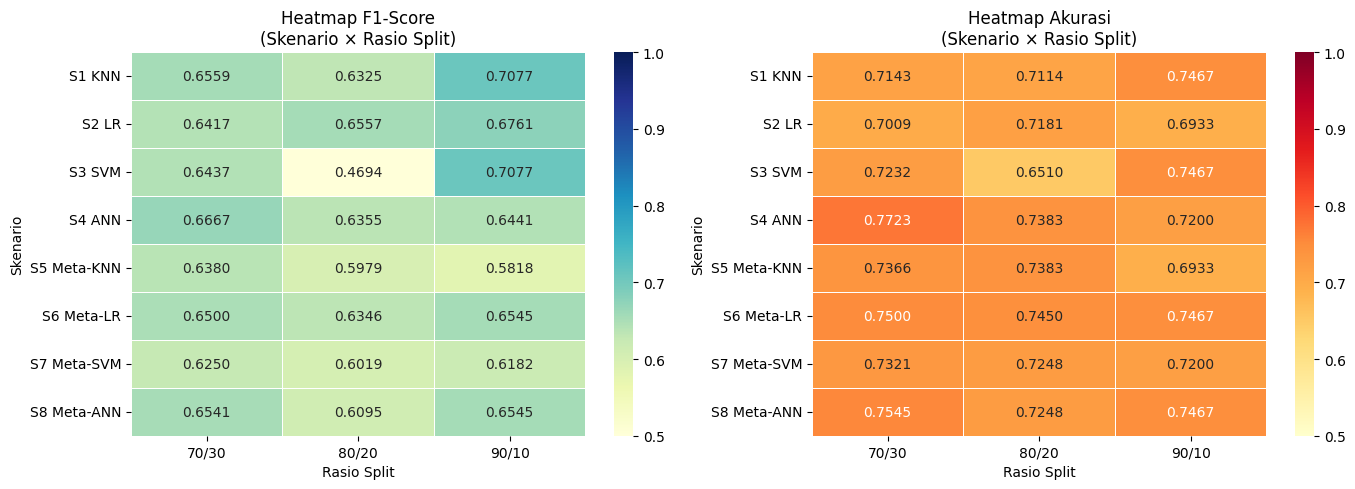

Gambar disimpan: heatmap_f1_akurasi.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(pivot.astype(float), annot=True, fmt=".4f", cmap="YlGnBu",
            linewidths=0.5, ax=axes[0], vmin=0.5, vmax=1.0)
axes[0].set_title("Heatmap F1-Score\n(Skenario × Rasio Split)", fontsize=12)
axes[0].set_xlabel("Rasio Split", fontsize=10)
axes[0].set_ylabel("Skenario", fontsize=10)

sns.heatmap(pivot_acc.astype(float), annot=True, fmt=".4f", cmap="YlOrRd",
            linewidths=0.5, ax=axes[1], vmin=0.5, vmax=1.0)
axes[1].set_title("Heatmap Akurasi\n(Skenario × Rasio Split)", fontsize=12)
axes[1].set_xlabel("Rasio Split", fontsize=10)
axes[1].set_ylabel("Skenario", fontsize=10)

plt.tight_layout()
plt.savefig("heatmap_f1_akurasi.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gambar disimpan: heatmap_f1_akurasi.png")

## 12. Line Plot – Tren F1-Score per Skenario

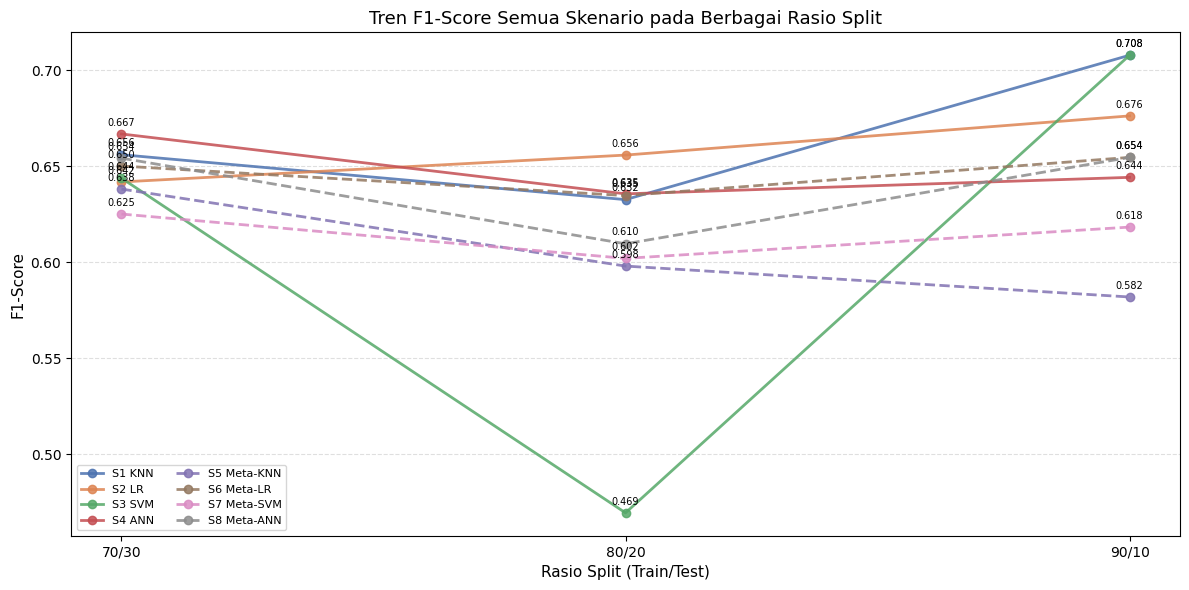

Gambar disimpan: lineplot_f1_semua_skenario.png


In [13]:
rasio_labels = list(RASIO_SPLIT.keys())
skenario_list = pivot.index.tolist()

colors_base    = ["#4C72B0","#DD8452","#55A868","#C44E52"]
colors_stacking= ["#8172B2","#937860","#DA8BC3","#8C8C8C"]
warna_map = dict(zip(skenario_list, colors_base + colors_stacking))
ls_map    = {s: ("-" if "S" + str(i+1) in s and i < 4 else "--")
             for i, s in enumerate(skenario_list)}

fig, ax = plt.subplots(figsize=(12, 6))
for s in skenario_list:
    vals = [pivot.loc[s, r] for r in rasio_labels]
    linestyle = "-" if any(x in s for x in ["KNN","LR","SVM","ANN"]) else "--"
    is_stacking = "Meta" in s
    ax.plot(rasio_labels, vals,
            marker="o", linewidth=2,
            label=s,
            color=warna_map.get(s, "gray"),
            linestyle="--" if is_stacking else "-",
            alpha=0.85)
    for rx, v in zip(rasio_labels, vals):
        ax.annotate(f"{v:.3f}", (rx, v), textcoords="offset points",
                    xytext=(0, 6), ha="center", fontsize=7)

ax.set_title("Tren F1-Score Semua Skenario pada Berbagai Rasio Split", fontsize=13)
ax.set_xlabel("Rasio Split (Train/Test)", fontsize=11)
ax.set_ylabel("F1-Score", fontsize=11)
ax.legend(loc="lower left", fontsize=8, ncol=2)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig("lineplot_f1_semua_skenario.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gambar disimpan: lineplot_f1_semua_skenario.png")

## 13. Confusion Matrix – Grid Semua Rasio × Semua Skenario

> Catatan: confusion matrix di-generate ulang menggunakan prediksi yang sudah tersimpan di `semua_hasil_rasio`.
> Karena prediksi per-sampel tidak disimpan di loop utama, cell ini mencetak tabel rekap saja.
> Untuk confusion matrix lengkap, jalankan cell berikut yang me-re-run hanya prediksi final (tanpa GridSearch ulang).

In [14]:
# Re-run prediksi ringan (hanya predict, model sudah ter-fit di loop atas)
# Catatan: variabel knn_final, lr_final, dst. di sini adalah hasil dari RASIO TERAKHIR (85/15).
# Untuk confusion matrix per-rasio, simpan model di loop atau jalankan ulang terpisah.
# Di sini kita tampilkan tabel rekap metrik sebagai gantinya.

skenario_urutan = ["S1 KNN", "S2 LR", "S3 SVM", "S4 ANN",
                   "S5 Meta-KNN", "S6 Meta-LR", "S7 Meta-SVM", "S8 Meta-ANN"]

for metrik in ["Akurasi", "Presisi", "Recall", "F1-Score"]:
    pv = df_rekap.pivot_table(index="Skenario", columns="Rasio Split",
                              values=metrik, aggfunc="first")
    pv = pv.reindex(columns=list(RASIO_SPLIT.keys()))
    print(f"\n{'='*55}")
    print(f"  {metrik}")
    print(f"{'='*55}")
    display(pv.round(4))


  Akurasi


Rasio Split,70/30,80/20,90/10
Skenario,,,
S1 KNN,0.7143,0.7114,0.7467
S2 LR,0.7009,0.7181,0.6933
S3 SVM,0.7232,0.6510,0.7467
S4 ANN,0.7723,0.7383,0.7200
S5 Meta-KNN,0.7366,0.7383,0.6933
S6 Meta-LR,0.7500,0.7450,0.7467
S7 Meta-SVM,0.7321,0.7248,0.7200
S8 Meta-ANN,0.7545,0.7248,0.7467



  Presisi


Rasio Split,70/30,80/20,90/10
Skenario,,,
S1 KNN,0.5446,0.5211,0.6389
S2 LR,0.5310,0.5263,0.5714
S3 SVM,0.5600,0.4423,0.6389
S4 ANN,0.6456,0.5574,0.6333
S5 Meta-KNN,0.5843,0.5686,0.6154
S6 Meta-LR,0.6047,0.5690,0.6923
S7 Meta-SVM,0.5814,0.5439,0.6538
S8 Meta-ANN,0.6118,0.5424,0.6923



  Recall


Rasio Split,70/30,80/20,90/10
Skenario,,,
S1 KNN,0.8243,0.8043,0.7931
S2 LR,0.8108,0.8696,0.8276
S3 SVM,0.7568,0.5000,0.7931
S4 ANN,0.6892,0.7391,0.6552
S5 Meta-KNN,0.7027,0.6304,0.5517
S6 Meta-LR,0.7027,0.7174,0.6207
S7 Meta-SVM,0.6757,0.6739,0.5862
S8 Meta-ANN,0.7027,0.6957,0.6207



  F1-Score


Rasio Split,70/30,80/20,90/10
Skenario,,,
S1 KNN,0.6559,0.6325,0.7077
S2 LR,0.6417,0.6557,0.6761
S3 SVM,0.6437,0.4694,0.7077
S4 ANN,0.6667,0.6355,0.6441
S5 Meta-KNN,0.6380,0.5979,0.5818
S6 Meta-LR,0.6500,0.6346,0.6545
S7 Meta-SVM,0.6250,0.6019,0.6182
S8 Meta-ANN,0.6541,0.6095,0.6545


## 14. Ringkasan – Rasio Terbaik per Skenario

In [15]:
ringkasan = []
for s in df_rekap["Skenario"].unique():
    sub = df_rekap[df_rekap["Skenario"] == s]
    best_row = sub.loc[sub["F1-Score"].idxmax()]
    ringkasan.append({
        "Skenario"       : s,
        "Rasio Terbaik"  : best_row["Rasio Split"],
        "Akurasi"        : best_row["Akurasi"],
        "Presisi"        : best_row["Presisi"],
        "Recall"         : best_row["Recall"],
        "F1-Score"       : best_row["F1-Score"],
    })

df_ringkasan = pd.DataFrame(ringkasan)
print("Rasio split terbaik per skenario (berdasarkan F1-Score tertinggi):")
display(df_ringkasan)

Rasio split terbaik per skenario (berdasarkan F1-Score tertinggi):


,Skenario,Rasio Terbaik,Akurasi,Presisi,Recall,F1-Score
0,S1 KNN,90/10,0.7467,0.6389,0.7931,0.7077
1,S2 LR,90/10,0.6933,0.5714,0.8276,0.6761
2,S3 SVM,90/10,0.7467,0.6389,0.7931,0.7077
3,S4 ANN,70/30,0.7723,0.6456,0.6892,0.6667
4,S5 Meta-KNN,70/30,0.7366,0.5843,0.7027,0.6380
5,S6 Meta-LR,90/10,0.7467,0.6923,0.6207,0.6545
6,S7 Meta-SVM,70/30,0.7321,0.5814,0.6757,0.6250
7,S8 Meta-ANN,90/10,0.7467,0.6923,0.6207,0.6545
